<a href="https://colab.research.google.com/github/ivannafav/Final-Data-Mining-Project/blob/main/Project_Health_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np  # For numerical computations and handling arrays/matrices.
import pandas as pd  # For data manipulation and analysis, including DataFrames for tabular data.
import matplotlib.pyplot as plt  # For creating static, interactive, and publication-quality visualizations.
import seaborn as sns  # For advanced data visualization, based on matplotlib, with additional features for statistical graphics.
from sklearn.preprocessing import StandardScaler  # For feature scaling to standardize input data.
from sklearn.model_selection import train_test_split  # For splitting datasets into training and testing sets.
from sklearn.metrics import confusion_matrix, classification_report  # For evaluating classification performance.
from sklearn import linear_model, metrics



# **Read the Dataset**

In [ ]:

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head(300)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,Female,50,Nurse,6.0,6,90,8,Overweight,140/95,75,10000,Sleep Apnea
296,297,Female,50,Nurse,6.1,6,90,8,Overweight,140/95,75,10000,Sleep Apnea
297,298,Female,50,Nurse,6.1,6,90,8,Overweight,140/95,75,10000,Sleep Apnea
298,299,Female,51,Engineer,8.5,9,30,3,Normal,125/80,65,5000,NaN


## **Checks and Cleaning the Data**

In [ ]:
#Basic checks

print(df["BMI Category"].value_counts())
print(df["Occupation"].value_counts())
print(df["Gender"].value_counts())

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64
Gender
Male      189
Female    185
Name: count, dtype: int64


In [ ]:
#Basic checks (2)

##Tells you rows,coluns
print(df.shape)

##Counts how many missing values (NaN) exist in each column
print(df.isna().sum())

##Shows you missing values - More detail (If missing values, check skewness before imputing!)
print(df.info())

##Shows how many null values
df.isnull().values.any()
df.isnull().sum()


(374, 13)
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [ ]:
print(df.shape)
print(df.isna().sum())

(374, 13)
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [ ]:
#Replace (1)

##Check to see if there are 0's that make no sense - Then replace with NaN

(df[["Sleep Duration", "BMI Category", "Age", "Blood Pressure", "Heart Rate"]] == 0).sum()

,0
Sleep Duration,0
BMI Category,0
Age,0
Blood Pressure,0
Heart Rate,0


In [ ]:
#Replace (2)

##Replace NaN with None

df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

##Replace Normal Weight with Normal

df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})

##Separate Diastolic/Systolic

bp_split = df["Blood Pressure"].str.split("/", expand=True)
df["Systolic BP"] = pd.to_numeric(bp_split[0], errors="coerce")
df["Diastolic BP"] = pd.to_numeric(bp_split[1], errors="coerce")

#Missing or invalid blood pressure entries become NaN (because of errors="coerce") → ready for imputation.




In [ ]:
#After Cleaning

(df.isna().sum())
df.head(20)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia,140,90
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None,120,80
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None,120,80
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None,120,80


## **Balanced Data**

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


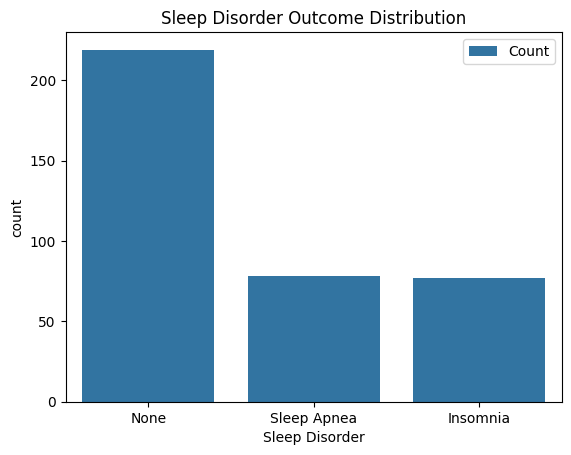

In [ ]:
#Check data

##Check

print(df["Sleep Disorder"].value_counts())

##Show data


sns.countplot(x = df['Sleep Disorder'],label="Count")
plt.title('Sleep Disorder Outcome Distribution')
plt.show()




In [ ]:
#Balance the data



## **Visualizing the Data**

**Histograms**

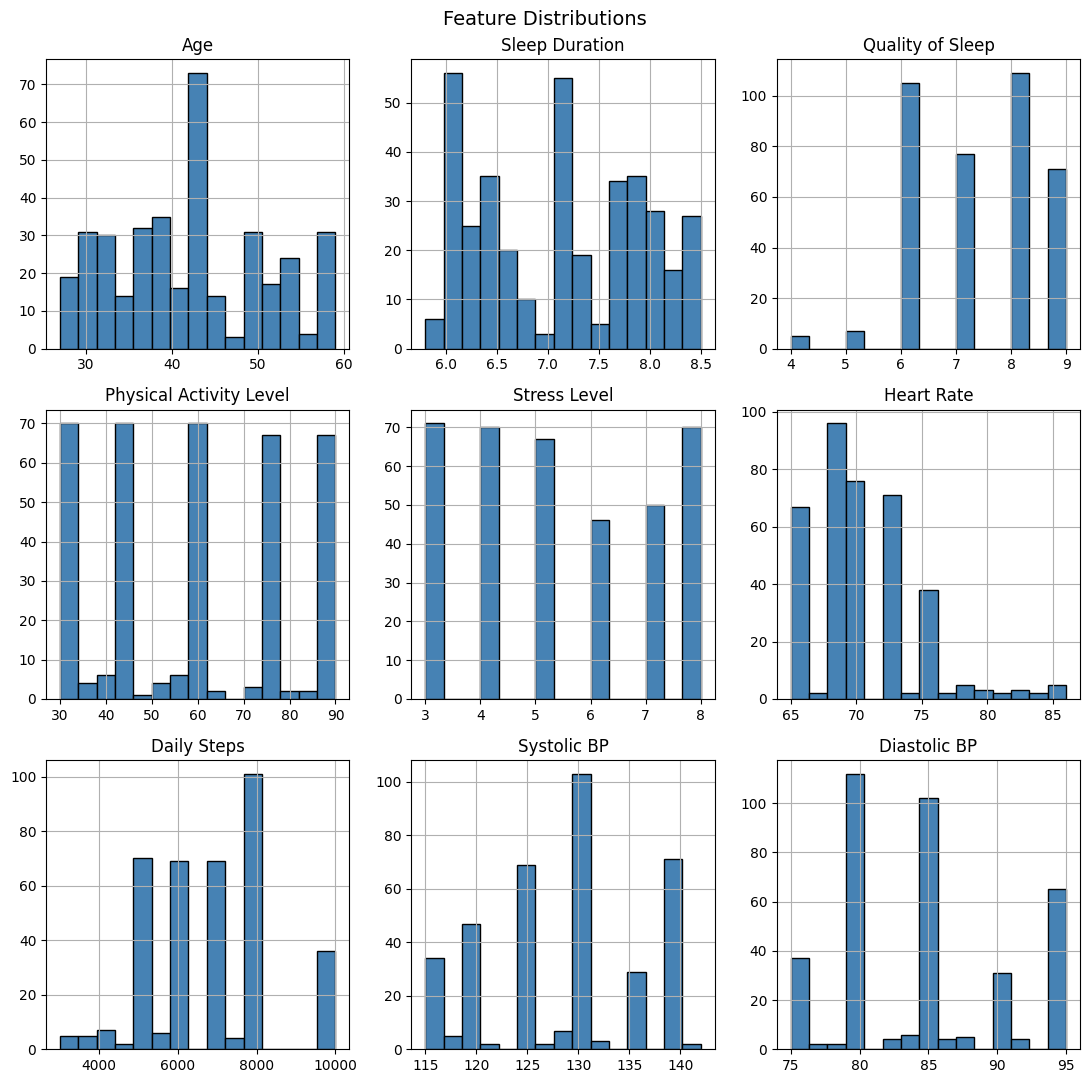

In [ ]:
#Histograms

#Define dataframe

numeric_cols = ["Age", "Sleep Duration", "Quality of Sleep",
                "Physical Activity Level", "Stress Level",
                "Heart Rate", "Daily Steps", "Systolic BP", "Diastolic BP"]


#Show histograms for dataframe

df[numeric_cols].hist(bins=15, figsize=(11, 11),color="steelblue", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

 **Outliers**

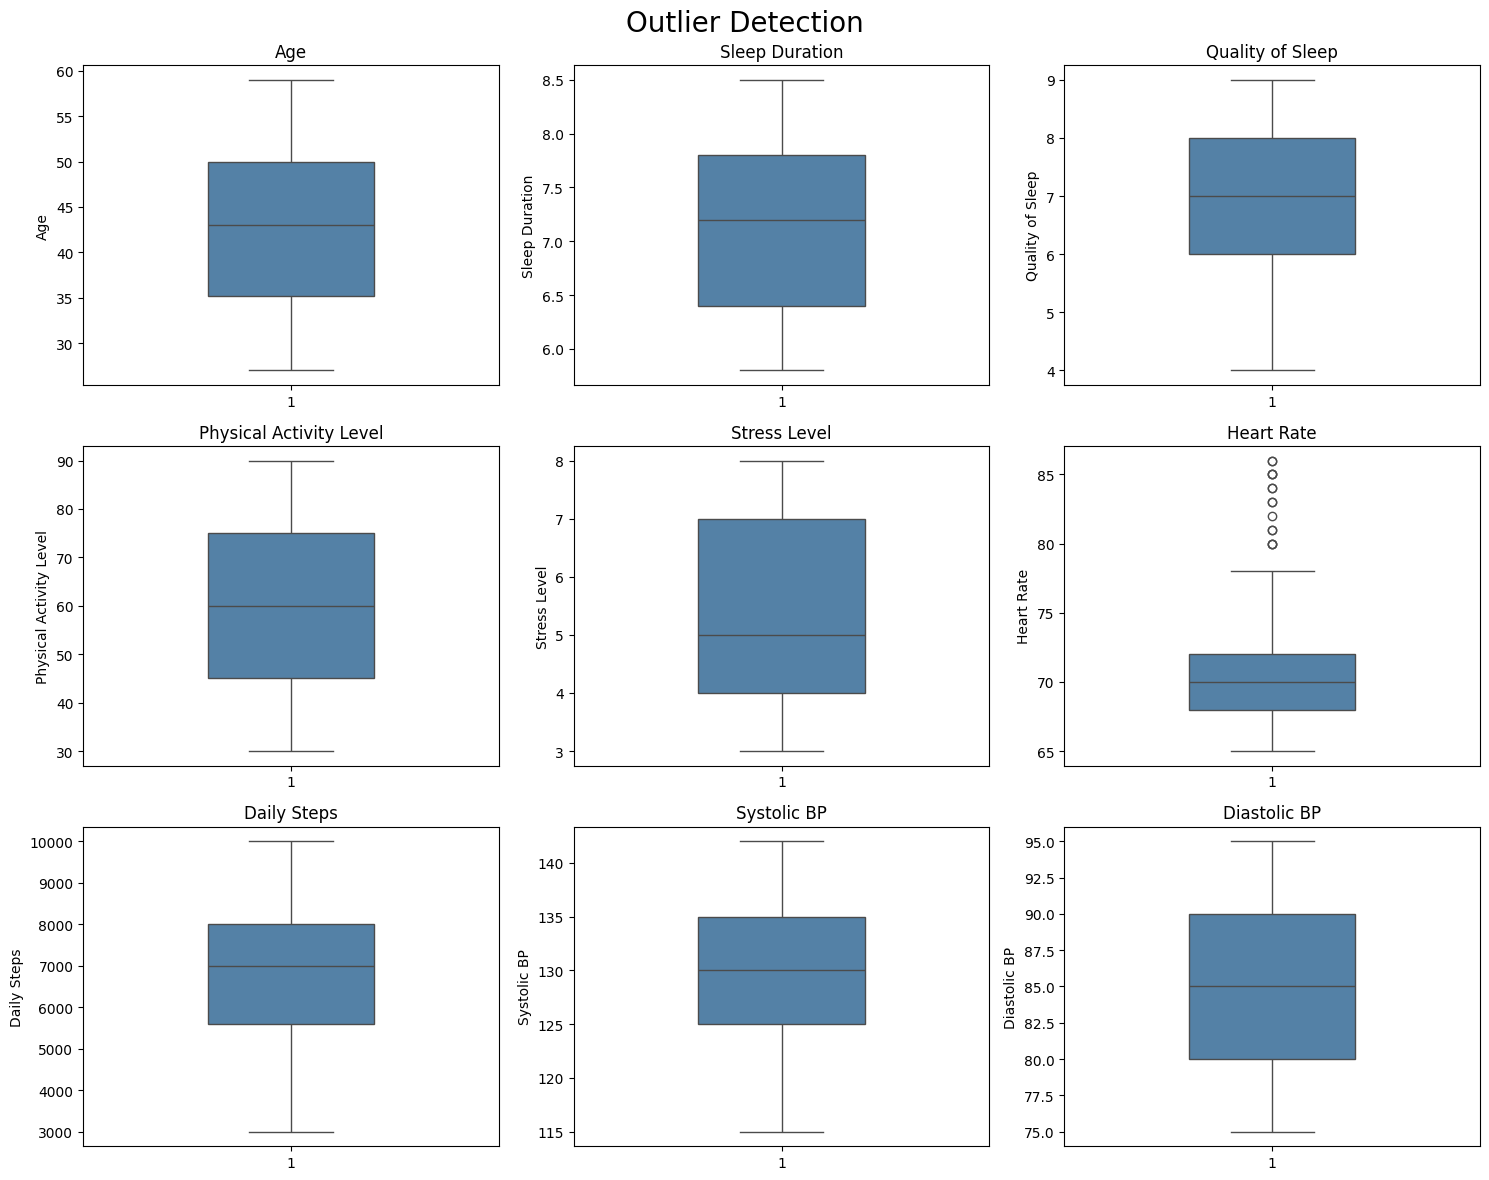

In [ ]:
#Outliers

##Create dataframe

numeric_cols = ["Age", "Sleep Duration", "Quality of Sleep",
                "Physical Activity Level", "Stress Level",
                "Heart Rate", "Daily Steps", "Systolic BP", "Diastolic BP"]

##Loop through each numeric column

# Loop through each numeric column
fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # Adjust size as needed
axes = axes.flatten()  # Flatten 2D array for easy looping

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=[1]*len(df),y=df[col], ax=axes[i], color="steelblue",width=0.4)
    axes[i].set_title(col, fontsize=12)

plt.suptitle("Outlier Detection", fontsize=20)
plt.tight_layout()
plt.show()



In [ ]:
#Handling outliers

Q1 = df["Heart Rate"].quantile(0.25)
Q3 = df["Heart Rate"].quantile(0.75)
IQR = Q3 - Q1

#Everything inside [Q1, Q3] is considered the middle 50% of the data
#Measures the spread of the middle 50% of your data

##Checking outliers

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

#Lower Bound → anything below this is considered a low outlier
#Upper Bound → anything above this is considered a high outlier
#Values inside [lower, upper] → considered “normal” or within expected range

outliers = df[(df["Heart Rate"] <= lower) | (df["Heart Rate"] >= upper)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower}, Upper bound: {upper}")
print(f"Min Heart Rate: {df['Heart Rate'].min()}, Max Heart Rate: {df['Heart Rate'].max()}")
print(f"Outliers detected: {len(outliers)}")


outliers = df[(df["Heart Rate"] < lower) | (df["Heart Rate"] > upper)]
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower}, Upper bound: {upper}")
print(f"Outliers detected: {len(outliers)}")
print(outliers["Heart Rate"].value_counts())


Q1: 68.0, Q3: 72.0, IQR: 4.0
Lower bound: 62.0, Upper bound: 78.0
Min Heart Rate: 65, Max Heart Rate: 86
Outliers detected: 20
Q1: 68.0, Q3: 72.0, IQR: 4.0
Lower bound: 62.0, Upper bound: 78.0
Outliers detected: 15
Heart Rate
85    3
80    3
81    2
83    2
84    2
86    2
82    1
Name: count, dtype: int64


In [ ]:
#Removing outliers

df_no_outliers = df[(df["Heart Rate"] >= lower) & (df["Heart Rate"] <= upper)].copy()

# Print the shape of the original and cleaned dataset
print(f"Original dataset size: {df.shape}")
print(f"Dataset size after removing outliers: {df_no_outliers.shape}")

Original dataset size: (374, 15)
Dataset size after removing outliers: (359, 15)


**Correlation**

<Axes: >

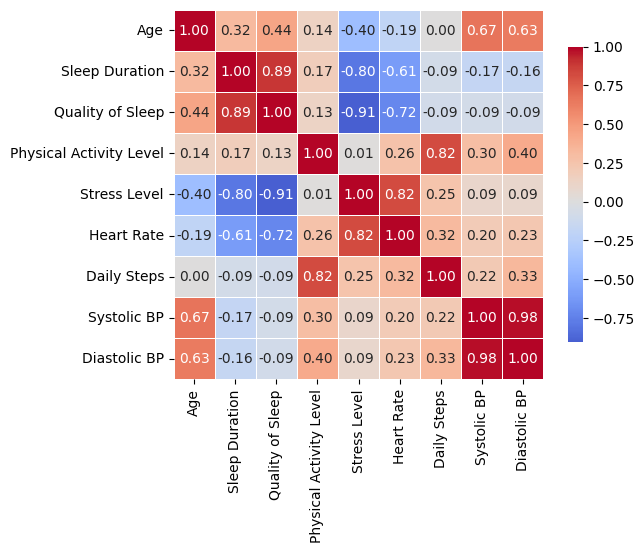

In [ ]:
#Heatmap

numeric_cols = ["Age", "Sleep Duration", "Quality of Sleep",
                "Physical Activity Level", "Stress Level",
                "Heart Rate", "Daily Steps", "Systolic BP", "Diastolic BP"]


numeric_data=df[numeric_cols]

corr = df_no_outliers[numeric_cols].corr()

sns.heatmap(corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8})

Assessment — three multicollinearity flags: Systolic BP vs Diastolic BP: 0.98 — this is near-perfect collinearity. One must be dropped. We will drop Diastolic BP and keep Systolic BP as it is the clinically more predictive measure.

Quality of Sleep vs Stress Level: -0.91 — very high. We keep both for now and Let VIF confirm whether one needs to go.

Sleep Duration vs Quality of Sleep: 0.89 and Sleep Duration vs Stress Level: -0.80 — same cluster. These three features are largely measuring the same underlying construct.

Physical Activity Level vs Daily Steps: 0.82 — another redundant pair to watch. VIF will quantify all of this precisely.

In [ ]:
#VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the numeric_data from your selected columns
X = numeric_data.copy()

# VIF requires no NaNs
X = X.dropna()

# Compute VIF for each column
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_data)



                   Feature          VIF
0              Systolic BP  9079.604067
1             Diastolic BP  7151.617327
2               Heart Rate   653.230640
3         Quality of Sleep   444.053809
4           Sleep Duration   409.493036
5             Stress Level    96.672717
6              Daily Steps    86.499895
7                      Age    68.003428
8  Physical Activity Level    31.536869


## **Feature Engineering**

Mean Arterial Pressure (MAP) = Diastolic + (1/3 x Pulse Pressure). Better physiological representation of average perfusion pressure. MAP is the stronger clinical choice.

**Creating New Feature and Redoing VIF**






In [ ]:
#Removing high VIF

df_clean = df_no_outliers.copy()

df_clean["MAP"] = df_clean["Diastolic BP"] + (1/3) * (df_clean["Systolic BP"] - df_clean["Diastolic BP"])

numeric_cols = ["Age", "Sleep Duration", "Physical Activity Level",
                "Stress Level", "MAP"]

vif_data = df_clean[numeric_cols].dropna()

vif_df = pd.DataFrame({
    "Feature": numeric_cols,
    "VIF": [variance_inflation_factor(vif_data.values, i)
            for i in range(len(numeric_cols))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_df)

final_features = ["Age", "Sleep Duration", "Physical Activity Level",
                  "Stress Level", "MAP"]

print("Final features:", final_features)
print("Shape:", df_clean[final_features].shape)

                   Feature         VIF
0                      MAP  294.881850
1           Sleep Duration   81.102633
2                      Age   61.653140
3             Stress Level   23.387314
4  Physical Activity Level   10.445902
Final features: ['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'MAP']
Shape: (359, 5)


Summary of what we dropped and why:
Diastolic BP: 0.98 correlation with Systolic, replaced by MAP
Systolic BP: replaced by MAP
Heart Rate: outlier-heavy, correlated 0.82 with Stress Level
Quality of Sleep: 0.89 correlation with Sleep Duration
Daily Steps: 0.82 correlation with Physical Activity Level
Reasoning:
MAP's VIF is being inflated by its correlation with Age and Sleep Duration — both of which have cardiovascular and physiological links to blood pressure. This is real-world clinical collinearity that cannot be engineered away without losing information.

More importantly: Naive Bayes assumes all features are conditionally independent by design. VIF is most critical for linear models that estimate joint coefficients.

The practical decision is to accept this feature set and document the multicollinearity as a known limitation.

**Binary** **Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Suppose df is your DataFrame
categorical_cols = ["Gender", "BMI Category", "Occupation", "Sleep Disorder"]

# Initialize encoder
le = LabelEncoder()

# Loop through categorical columns
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# Build final modeling dataframe
model_features = ["Age", "Sleep Duration", "Physical Activity Level",
                  "Stress Level", "MAP", "Gender", "BMI Category", "Occupation"]

X = df_clean[model_features]
y = df_clean["Sleep Disorder"]

print(X.shape, y.shape)
print(y.value_counts())

(359, 8) (359,)
Sleep Disorder
1    219
0     71
2     69
Name: count, dtype: int64


**SMOT and Scale**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale after splitting — fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Train before SMOTE:", y_train.value_counts().to_dict())
print("Train after SMOTE: ", pd.Series(y_train_bal).value_counts().to_dict())
print("Test set:          ", y_test.value_counts().to_dict())

Train before SMOTE: {1: 175, 0: 57, 2: 55}
Train after SMOTE:  {1: 175, 0: 175, 2: 175}
Test set:           {1: 44, 0: 14, 2: 14}


**Split**

The reason you split first is because of one concept:

Your test set must represent data the model has NEVER seen before.

Think of it like this:

You are building a model to predict sleep disorders for future patients.

The test set = future patients.

If you let your model “peek” at those future patients while preparing the data, your evaluation becomes fake.

**Scale**

Scaling makes features comparable.

Example:

Age → ranges 20–70

Daily Steps → ranges 1,000–15,000

Without scaling:

Models think “Daily Steps” is more important just because the numbers are bigger.

Scaling transforms everything to:

Mean = 0

Std = 1

Models that NEED scaling:

Logistic Regression

SVM

KNN

Naive Bayes (Gaussian version)

Models that don’t care much:

Random Forest

Decision Trees

**SMOT**

SMOTE is for class imbalance.

Example:

300 “No Disorder”

40 “Apnea”

Without SMOTE:

Model predicts “No Disorder” for everything.

Accuracy looks high.

But model is useless.

SMOTE creates synthetic minority examples in training.

Important:

You only SMOTE the training set.

Why?

Because the test set must reflect real-world imbalance.
You don’t artificially balance reality.

## **Naive Bayes**

In [ ]:
import time
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn import metrics, naive_bayes
import seaborn as sns
import matplotlib.pyplot as plt





In [ ]:
#Classifier

Naive_bayes_G = naive_bayes.GaussianNB()
#Create Guassian Naive Bayes classifier

Naive_bayes_G.fit(X_train, y_train)
#fit the classifier to your training data
#scale or no scale data - doesn't matter!

GaussianNB()

In [ ]:
#Predictions

y_pred_G = Naive_bayes_G.predict(X_test)
print(y_pred_G)

probalilities_G = Naive_bayes_G.predict_proba(X_test)
print(f"Estiamted Probabilities:{probalilities_G[:10]}")

#class with the highest probability will be selected. First one class 0 and the second one class 1.

[0 1 1 2 0 0 1 1 2 1 1 1 1 2 1 2 1 1 1 1 2 1 1 2 2 2 0 1 2 0 1 1 1 1 1 1 0
 1 1 1 1 1 1 2 0 1 1 1 1 1 1 2 1 1 2 0 0 0 1 1 0 0 1 1 2 0 1 0 1 1 0 1]
Estiamted Probabilities:[[9.99944008e-01 3.91002122e-05 1.68919049e-05]
 [1.27125592e-06 9.99998729e-01 1.37150535e-12]
 [8.26132522e-11 9.99999717e-01 2.83404923e-07]
 [2.98538850e-10 1.13253719e-07 9.99999886e-01]
 [9.99994063e-01 4.45981800e-07 5.49061531e-06]
 [9.99993339e-01 1.69245573e-06 4.96860509e-06]
 [1.62264592e-11 1.00000000e+00 6.41029176e-12]
 [2.79378350e-08 9.99997864e-01 2.10853836e-06]
 [4.23143055e-06 7.48330416e-08 9.99995694e-01]
 [9.50786686e-10 9.99999752e-01 2.46570962e-07]]


Accuracy: 0.8611111111111112



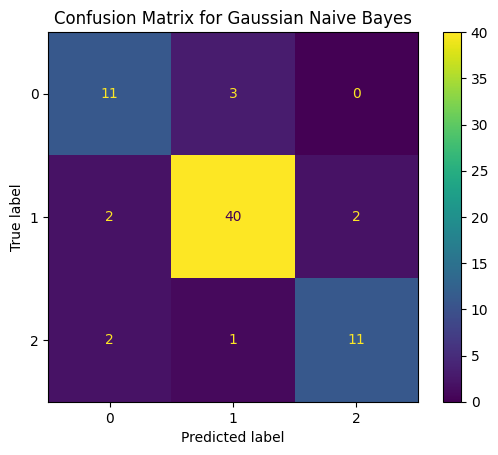

              precision    recall  f1-score   support

    Insomnia       0.73      0.79      0.76        14
        None       0.91      0.91      0.91        44
 Sleep Apnea       0.85      0.79      0.81        14

    accuracy                           0.86        72
   macro avg       0.83      0.83      0.83        72
weighted avg       0.86      0.86      0.86        72



In [ ]:
#Confusion Matrix
acc_G = metrics.accuracy_score(y_test, y_pred_G)
print(f"Accuracy: {acc_G}\n")

confusion_mat_G = metrics.confusion_matrix(y_test, y_pred_G)
confusion_mat_G
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_G)
plt.title("Confusion Matrix for Gaussian Naive Bayes")
plt.show()


print(classification_report(y_test, y_pred_G, target_names=["Insomnia", "None", "Sleep Apnea"]))



In [ ]:
#Cross Validation

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#Purpose: splits your dataset into 10 folds for cross-validation.
#Stratified: ensures that the proportion of each class (0,1,2) is preserved in every fold.
#shuffle=True: randomly shuffles the data before splitting (to avoid order bias).
#random_state=42: makes the shuffle reproducible.

cv_scores = cross_val_score(Naive_bayes_G, X_train_bal, y_train_bal, cv=skf, scoring="accuracy")

#10-fold stratified cross-validation on your training data using GaussianNB
#Returning the accuracy foreach fold in an array.


print("CV Accuracy per fold:", cv_scores.round(3))
#Shows the accuracy for each fold, rounded to 3 decimal places.

print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
#Rounds that number to 4 decimal places.

print("Std CV Accuracy:", round(cv_scores.std(), 4))

CV Accuracy per fold: [0.906 0.943 0.887 0.887 0.887 0.981 0.962 0.885 0.865 0.981]
Mean CV Accuracy: 0.9183
Std CV Accuracy: 0.0417


In [ ]:
#Runtime

start = time.time()
Naive_bayes_G.fit(X_train_bal, y_train_bal)
end = time.time()

y_pred = Naive_bayes_G.predict(X_test_scaled)

print("Runtime:", round(end - start, 4), "seconds")

Runtime: 0.0058 seconds


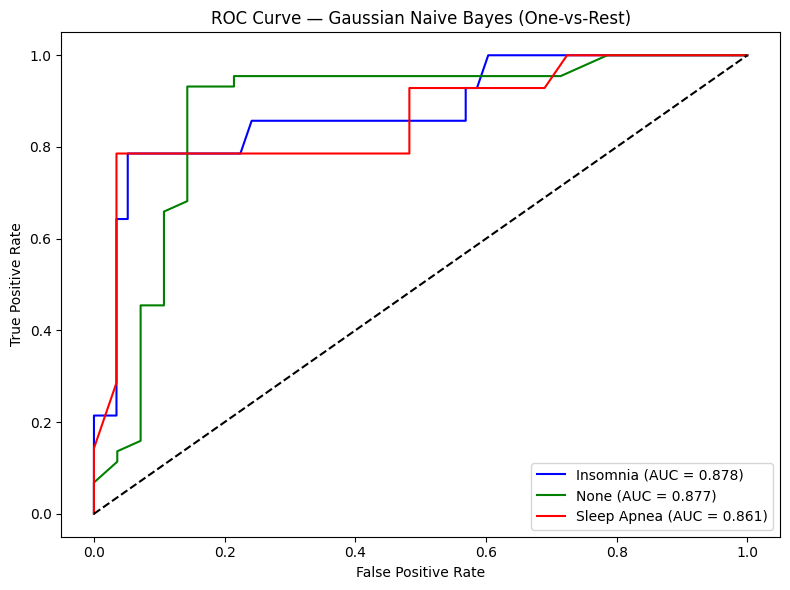

Macro AUC: 0.8718


In [ ]:
#ROC

from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.metrics import roc_auc_score, roc_curve


y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_prob = Naive_bayes_G.predict_proba(X_test_scaled)

#y_test has 3 classes (0 = Insomnia, 1 = None, 2 = Sleep Apnea).
#label_binarize converts them into a one-hot encoded format required for multi-class ROC/AUC

class_names = ["Insomnia", "None", "Sleep Apnea"]
colors = cycle(["blue", "green", "red"])

plt.figure(figsize=(8, 6))
for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC = {auc:.3f})")

#Loops over each class: Treats the current class as “positive” and all others as “negative” (One-vs-Rest).
#Calculates metrics: Computes the ROC curve (FPR vs TPR) and the AUC for that class.
#Plots the curve: Draws the ROC line for this class on the graph with a specific color and label.

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Gaussian Naive Bayes (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Macro AUC:", round(roc_auc_score(y_test_bin, y_prob, multi_class="ovr"), 4))


## **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import time

In [ ]:
#LR

lr = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000, random_state=42)

#multi_class → how to handle >2 classes (OvR vs multinomial).
#solver → algorithm that fits the model. (lbfgs> fast, good for small/medium datasets, supports multinomial (softmax) for multi-class.)
#max_iter → how long the solver can try to converge. (converge=best solution)


##Train

lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test_scaled)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.8472222222222222



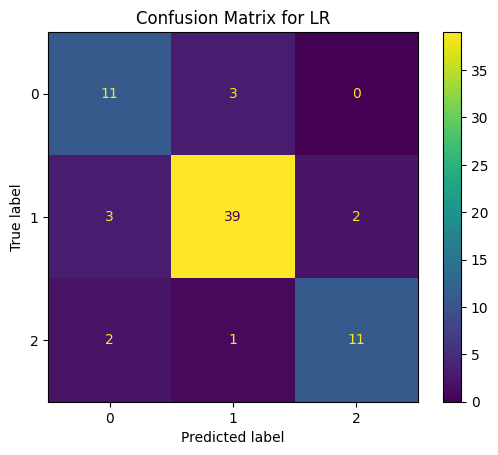

              precision    recall  f1-score   support

    Insomnia       0.69      0.79      0.73        14
        None       0.91      0.89      0.90        44
 Sleep Apnea       0.85      0.79      0.81        14

    accuracy                           0.85        72
   macro avg       0.81      0.82      0.81        72
weighted avg       0.85      0.85      0.85        72



In [ ]:
#Confusion Matrix
acc_lr = metrics.accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr}\n")

confusion_mat_lr = metrics.confusion_matrix(y_test, y_pred_lr)
confusion_mat_lr
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Confusion Matrix for LR")
plt.show()

#Table

print(classification_report(y_test, y_pred_lr, target_names=["Insomnia", "None", "Sleep Apnea"]))

In [ ]:
#Cross Validation

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#Purpose: splits your dataset into 10 folds for cross-validation.
#Stratified: ensures that the proportion of each class (0,1,2) is preserved in every fold.
#shuffle=True: randomly shuffles the data before splitting (to avoid order bias).
#random_state=42: makes the shuffle reproducible.

cv_scores = cross_val_score(lr, X_train_bal, y_train_bal, cv=skf, scoring="accuracy")

#10-fold stratified cross-validation on your training data using GaussianNB
#Returning the accuracy foreach fold in an array.


print("CV Accuracy per fold:", cv_scores.round(3))
#Shows the accuracy for each fold, rounded to 3 decimal places.

print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
#Rounds that number to 4 decimal places.

print("Std CV Accuracy:", round(cv_scores.std(), 4))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

CV Accuracy per fold: [0.906 0.943 0.906 0.868 0.906 0.981 0.962 0.904 0.865 1.   ]
Mean CV Accuracy: 0.924
Std CV Accuracy: 0.0433


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
#Runtime

start = time.time()
lr.fit(X_train_bal, y_train_bal)
end = time.time()

y_pred = lr.predict(X_test_scaled)

print("Runtime:", round(end - start, 4), "seconds")

Runtime: 0.0309 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


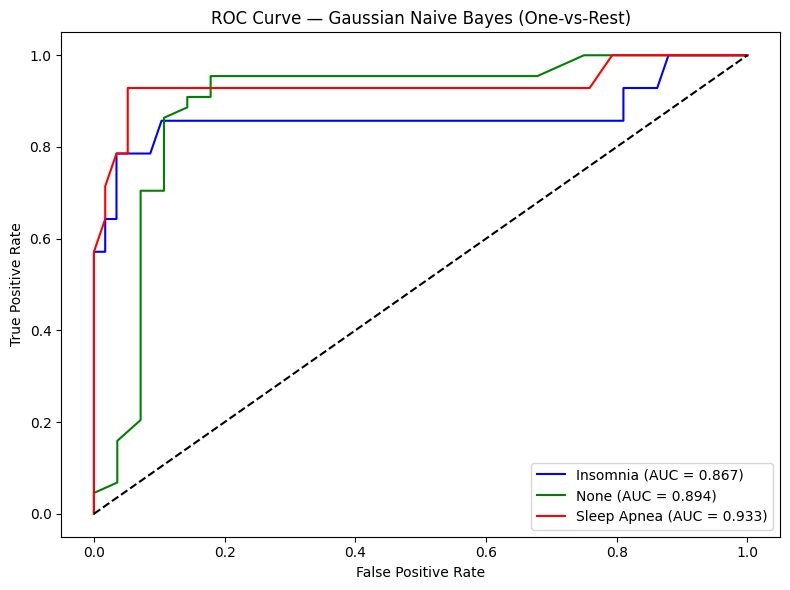

Macro AUC: 0.8983


In [ ]:
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.metrics import roc_auc_score, roc_curve


y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_prob = lr.predict_proba(X_test_scaled)

#y_test has 3 classes (0 = Insomnia, 1 = None, 2 = Sleep Apnea).
#label_binarize converts them into a one-hot encoded format required for multi-class ROC/AUC

class_names = ["Insomnia", "None", "Sleep Apnea"]
colors = cycle(["blue", "green", "red"])

plt.figure(figsize=(8, 6))
for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC = {auc:.3f})")

#Loops over each class: Treats the current class as “positive” and all others as “negative” (One-vs-Rest).
#Calculates metrics: Computes the ROC curve (FPR vs TPR) and the AUC for that class.
#Plots the curve: Draws the ROC line for this class on the graph with a specific color and label.

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Gaussian Naive Bayes (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Macro AUC:", round(roc_auc_score(y_test_bin, y_prob, multi_class="ovr"), 4))


## **GPC**

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, DotProduct
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import time


--- Gaussian Process Classifier (RBF Kernel) ---

Accuracy: 0.875

Training runtime: 25.7368 seconds

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.79      0.79      0.79        14
        None       0.91      0.93      0.92        44
 Sleep Apnea       0.85      0.79      0.81        14

    accuracy                           0.88        72
   macro avg       0.85      0.83      0.84        72
weighted avg       0.87      0.88      0.87        72



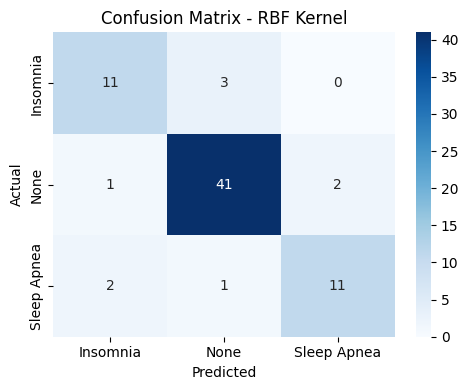


--- Gaussian Process Classifier (DotProduct Kernel) ---



/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__sigma_0 is close to the specified lower bound 0.5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Accuracy: 0.8472222222222222

Training runtime: 5.8915 seconds

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.71      0.71      0.71        14
        None       0.91      0.91      0.91        44
 Sleep Apnea       0.79      0.79      0.79        14

    accuracy                           0.85        72
   macro avg       0.80      0.80      0.80        72
weighted avg       0.85      0.85      0.85        72



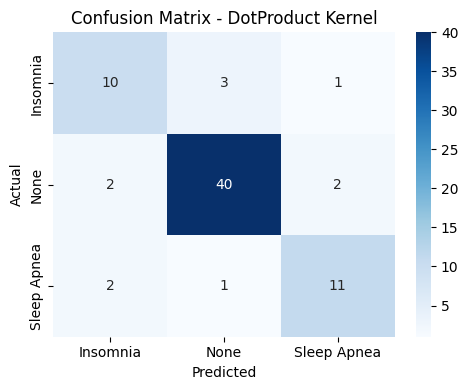

In [ ]:
#Define Kernels
kernels = [
    1.0 * RBF(length_scale=1.15, length_scale_bounds=(0.1, 10.0)),  # length_scale can be optimized between 0.1 and 10.0, This will allow the model to optimize the length_scale within the range 1e-2 to 1e2.
    1.0 * DotProduct(sigma_0=1.2, sigma_0_bounds=(0.5, 5.0))  # sigma_0 can be optimized between 0.5 and 5.0
]


#Kernel Names
kernel_names = ["RBF", "DotProduct"]


#Loop through each kernel to train, predict, and evaluate
for kernel, name in zip(kernels, kernel_names):
    print(f"\n--- Gaussian Process Classifier ({name} Kernel) ---\n")

    # Create and fit the classifier
    clf = GaussianProcessClassifier(kernel=kernel, warm_start=False)
    #Fitting a new model for each kernel (i.e., switching to a completely new kernel on each loop iteration).
    #Not continuing training from the previously optimized kernel parameters.

    #Measure runtime separately
    start_time = time.time() #Mark the start

     #Train
    clf.fit(X_train_bal, y_train_bal)

    runtime = round(time.time() - start_time, 4) #Mark the elapsed time
    #time.time() gives the current time in seconds since a fixed point (the epoch).
       #You store that value in start_time.
       #This is meant to mark the moment training begins.


    #Make predictions
    y_preds = clf.predict(X_test_scaled) #must be scaled!
    y_probs = clf.predict_proba(X_test_scaled) #must be scaled!

    #Accuracy
    acc_G = metrics.accuracy_score(y_test, y_preds)
    print(f"Accuracy: {acc_G}\n")
    print(f"Training runtime: {runtime} seconds")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_preds, target_names=["Insomnia", "None", "Sleep Apnea"]))

    #Confusion Matrix
    cm = confusion_matrix(y_test, y_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Insomnia", "None", "Sleep Apnea"],
                yticklabels=["Insomnia", "None", "Sleep Apnea"])
    plt.title(f"Confusion Matrix - {name} Kernel")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


## **Model Comparison**

Sensitivity and Specificity per Class (Insomnia / None / Sleep Apnea)

Gaussian Naive Bayes:
  Insomnia: Sensitivity=0.786, Specificity=0.931
  None: Sensitivity=0.909, Specificity=0.857
  Sleep Apnea: Sensitivity=0.786, Specificity=0.966

Logistic Regression (C=100):
  Insomnia: Sensitivity=0.786, Specificity=0.914
  None: Sensitivity=0.886, Specificity=0.857
  Sleep Apnea: Sensitivity=0.786, Specificity=0.966

GPC (RBF):
  Insomnia: Sensitivity=0.714, Specificity=0.931
  None: Sensitivity=0.909, Specificity=0.857
  Sleep Apnea: Sensitivity=0.786, Specificity=0.948

                      Model  CV Mean Accuracy  CV Std  Test Accuracy  Macro Precision  Macro Recall  Macro F1  Runtime (s)
       Gaussian Naive Bayes            0.9183  0.0417           0.86             0.83          0.83      0.83       0.0025
Logistic Regression (C=100)            0.9278  0.0433           0.86             0.83          0.84      0.83       0.0933
                  GPC (RBF)            0.9335  0.0351    

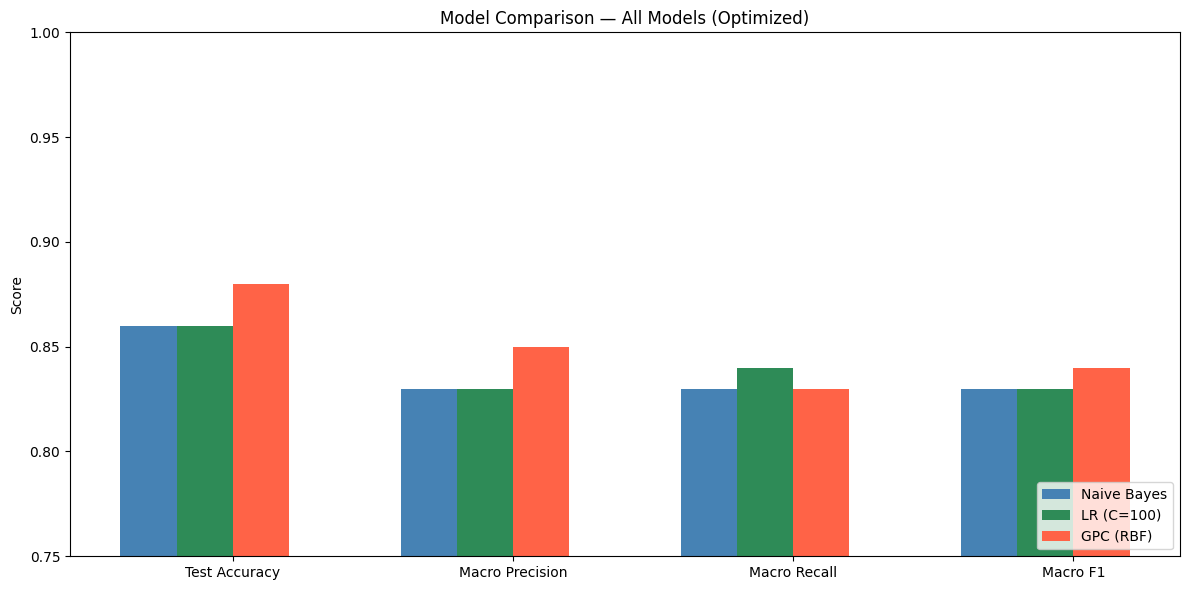

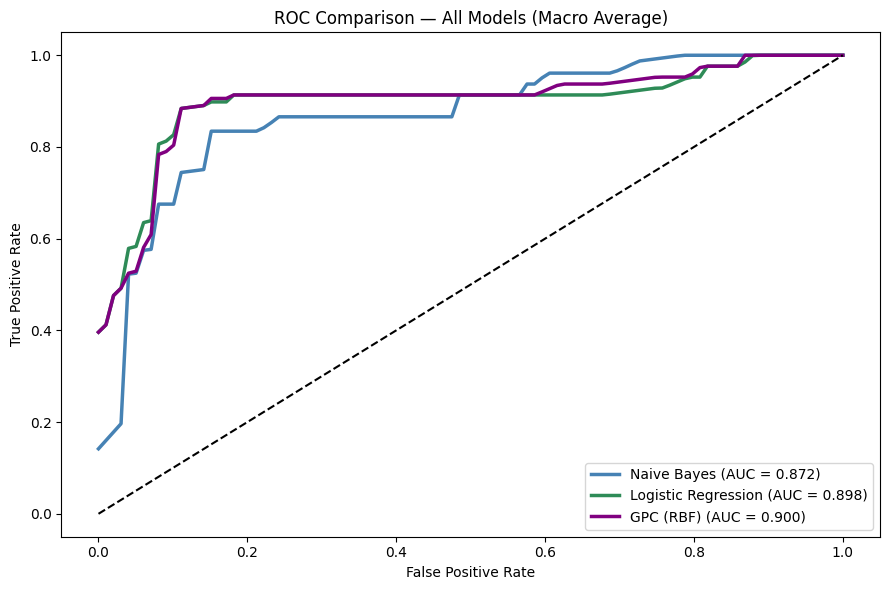

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Helper function for sensitivity and specificity in multiclass
def sensitivity_specificity(y_true, y_pred, n_classes=3):
    results = []
    for c in range(n_classes):
        y_true_bin = (y_true == c).astype(int)
        y_pred_bin = (y_pred == c).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        results.append((round(sensitivity, 3), round(specificity, 3)))
    return results

# Compute per-model sensitivity and specificity
models_eval = {
    "Gaussian Naive Bayes":        (y_pred_G,        Naive_bayes_G),
    "Logistic Regression (C=100)": (y_pred_lr, LogisticRegression),
    "GPC (RBF)":                   (y_preds,    clf)
}

print("Sensitivity and Specificity per Class (Insomnia / None / Sleep Apnea)\n")
for model_name, (preds, _) in models_eval.items():
    ss = sensitivity_specificity(y_test.values, preds)
    print(f"{model_name}:")
    for i, cls in enumerate(["Insomnia", "None", "Sleep Apnea"]):
        print(f"  {cls}: Sensitivity={ss[i][0]}, Specificity={ss[i][1]}")
    print()

# Updated results table
results = pd.DataFrame({
    "Model":              ["Gaussian Naive Bayes", "Logistic Regression (C=100)",
                          "GPC (RBF)"],
    "CV Mean Accuracy":   [0.9183, 0.9278, 0.9335],
    "CV Std":             [0.0417, 0.0433, 0.0351],
    "Test Accuracy":      [0.86,   0.86,   0.88],
    "Macro Precision":    [0.83,   0.83,   0.85],
    "Macro Recall":       [0.83,   0.84,   0.83],
    "Macro F1":           [0.83,   0.83,   0.84],
    "Runtime (s)":        [0.0025, 0.0933, 0.0026, 9.9207]
})
print(results.to_string(index=False))

# Updated bar chart
metrics_names = ["Test Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
scores = {
    "Naive Bayes":      [0.86, 0.83, 0.83, 0.83],
    "LR (C=100)":       [0.86, 0.83, 0.84, 0.83],
    "GPC (RBF)":        [0.88, 0.85, 0.83, 0.84],
}

x = np.arange(len(metrics_names))
width = 0.2
colors = ["steelblue", "seagreen", "tomato", "purple"]

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model, vals) in enumerate(scores.items()):
    ax.bar(x + i * width, vals, width, label=model, color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — All Models (Optimized)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Updated ROC comparison
plt.figure(figsize=(9, 6))
optimized_models = [
    ("Naive Bayes",             Naive_bayes_G,                      "steelblue"),
    ("Logistic Regression",     lr,  "seagreen"),
    ("GPC (RBF)",               clf,                      "purple")
]

for name, model, color in optimized_models:
    y_prob = model.predict_proba(X_test_scaled)
    macro_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")
    fpr_avg = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(fpr_avg)
    for i in range(3):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        mean_tpr += np.interp(fpr_avg, fpr_i, tpr_i)
    mean_tpr /= 3
    plt.plot(fpr_avg, mean_tpr, color=color, linewidth=2.5,
             label=f"{name} (AUC = {macro_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison — All Models (Macro Average)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:

# Helper function for sensitivity and specificity in multiclass
def sensitivity_specificity(y_true, y_pred, n_classes=3):
    results = []
    for c in range(n_classes):
        y_true_bin = (y_true == c).astype(int)
        y_pred_bin = (y_pred == c).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        results.append((round(sensitivity, 3), round(specificity, 3)))
    return results

#y_true → the true labels for your test set.
#y_pred → predicted labels from your model.
#n_classes → number of classes (3 for your sleep dataset: Insomnia, None, Sleep Apnea).
#Multiclass specificity does not exist automatically — you must compute it manually using One-vs-Rest logic.
#c in range: We handle one class at a time.
 #For c=0 → Insomnia is treated as positive, all others are negative.
 #For c=1 → None is positive, rest negative.
 #For c=2 → Sleep Apnea is positive.
#y_true
 #(y_true == c) → returns a Boolean array: True if the sample is class c, False otherwise.
 #.astype(int) → converts Boolean to 0/1.


In [ ]:
# Compute per-model sensitivity and specificity
models_eval = {
    "Gaussian Naive Bayes":        (y_pred_G,        Naive_bayes_G),
    "Logistic Regression (C=100)": (y_pred_lr, LogisticRegression),
    "GPC (RBF)":                   (y_preds,    clf)
}
#Dictionnary

print("Sensitivity and Specificity per Class (Insomnia / None / Sleep Apnea)\n")
for model_name, (preds, _) in models_eval.items():
    ss = sensitivity_specificity(y_test.values, preds)
    print(f"{model_name}:")
    for i, cls in enumerate(["Insomnia", "None", "Sleep Apnea"]):
        print(f"  {cls}: Sensitivity={ss[i][0]}, Specificity={ss[i][1]}")
    print()

#ss = [...]
   #It compares true labels (y_test)
   #With predictions (preds)
   #Calculates sensitivity & specificity for all 3 classes
   #result >(sens.,spec.)
#enumerate
   #This turns the list into indexed pairs:
    #(0, "Insomnia")
    #(1, "None")
    #(2, "Sleep Apnea")
#ss[i] → gives the tuple for that class.
   #ss[i][0] → sensitivity.
   #ss[i][1] → specificity.

In [ ]:
# Updated results table
results = pd.DataFrame({
    "Model":              ["Gaussian Naive Bayes", "Logistic Regression (C=100)",
                          "GPC (RBF)"],
    "CV Mean Accuracy":   [0.9183, 0.9278, 0.9335],
    "CV Std":             [0.0417, 0.0433, 0.0351],
    "Test Accuracy":      [0.86,   0.86,   0.88],
    "Macro Precision":    [0.83,   0.83,   0.85],
    "Macro Recall":       [0.83,   0.84,   0.83],
    "Macro F1":           [0.83,   0.83,   0.84],
    "Runtime (s)":        [0.0025, 0.0933, 9.9207]
})
print(results.to_string(index=False))

#pd.DataFrame({...}) → creates a table-like structure in pandas.
#Each key (like "Model") becomes a column name.
#Each value (the list) is a column of data, with each item corresponding to a row.
#.to_string() converts the DataFrame into a text table that can be printed neatly in the console.
#index=False tells pandas not to print the row numbers (0, 1, 2) on the left, so the table looks cleaner.

In [ ]:
# Updated bar chart
metrics_names = ["Test Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
scores = {
    "Naive Bayes":      [0.86, 0.83, 0.83, 0.83],
    "LR (C=100)":       [0.86, 0.83, 0.84, 0.83],
    "GPC (RBF)":        [0.88, 0.85, 0.83, 0.84],
}

x = np.arange(len(metrics_names))
width = 0.2
colors = ["steelblue", "seagreen", "tomato", "purple"]

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model, vals) in enumerate(scores.items()):
    ax.bar(x + i * width, vals, width, label=model, color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — All Models (Optimized)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

#metrics_names → The metrics you want to plot.
#scores → A dictionary where each key is a model name and each value is a list of the corresponding metric scores (in the same order as metrics_names).
#metrics_names → The metrics you want to plot.
#len(metrics_names) → gives 4.
#np.arange(4) → creates an array [0, 1, 2, 3].
   #So x represents the base x-axis positions for each metric.
    #0 → "Test Accuracy"
    #1 → "Macro Precision"
    #2 → "Macro Recall"
    #3 → "Macro F1"
  #x + i * width so the bars for different models don’t overlap.

In [ ]:
# Updated ROC comparison
plt.figure(figsize=(9, 6))
optimized_models = [
    ("Naive Bayes",             Naive_bayes_G,                      "steelblue"),
    ("Logistic Regression",     lr,  "seagreen"),
    ("GPC (RBF)",               clf,                      "purple")
]

for name, model, color in optimized_models:
    y_prob = model.predict_proba(X_test_scaled)
    macro_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")
    fpr_avg = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(fpr_avg)
    for i in range(3):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        mean_tpr += np.interp(fpr_avg, fpr_i, tpr_i)
    mean_tpr /= 3
    plt.plot(fpr_avg, mean_tpr, color=color, linewidth=2.5,
             label=f"{name} (AUC = {macro_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison — All Models (Macro Average)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#1

#plt.figure(figsize=(9, 6)) → creates a plotting canvas, 9 inches wide × 6 inches tall.
#optimized_models → a list of tuples where each tuple contains:
#Name of the model (string)
#Trained model object (so you can call .predict_proba)
#Color for the plot line



#2

#model.predict_proba(X_test_scaled) → predicts probabilities for each class in the test set.
#For 3 classes, it returns something like:
   #[[0.9, 0.05, 0.05],



#3

#y_test_bin → one-hot encoded true labels (3 columns for 3 classes).
#roc_auc_score(..., multi_class="ovr") → calculates macro-average AUC using One-vs-Rest strategy: treats each class as "positive" vs all others.


#4

#np.linspace(0, 1, 100) → creates 100 points evenly spaced from 0 to 1 for FPR (x-axis).
#mean_tpr → initialized as zeros; will store the average True Positive Rate across classes.
#Loop over each class i (0,1,2):
#roc_curve(y_test_bin[:, i], y_prob[:, i]) → computes FPR & TPR for class i.
#np.interp(fpr_avg, fpr_i, tpr_i) → interpolates the TPR at the common FPR points so all classes align on the same x-axis.
#mean_tpr /= 3 → averages TPR across the 3 classes → macro-average ROC curve.